This notebook estimates the CAPM beta of a stock using regression
between stock returns and market index returns.

import libraries:

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


Download price data:

In [2]:
stock_ticker = "HDFCBANK.NS"
market_ticker = "^NSEI"

start_date = "2018-01-01"

stock = yf.download(stock_ticker, start=start_date, progress=False)
market = yf.download(market_ticker, start=start_date, progress=False)

stock.head(), market.head()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19004\52012659.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(stock_ticker, start=start_date, progress=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19004\52012659.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download(market_ticker, start=start_date, progress=False)


(Price            Close        High         Low        Open      Volume
 Ticker     HDFCBANK.NS HDFCBANK.NS HDFCBANK.NS HDFCBANK.NS HDFCBANK.NS
 Date                                                                  
 2018-01-01  432.688995  438.813604  431.755722  436.935379     6580516
 2018-01-02  436.853699  437.471998  433.633922  433.633922     4776316
 2018-01-03  432.257446  438.230393  431.919117  437.472108     4531288
 2018-01-04  433.948914  435.255491  432.339011  432.339011     2373776
 2018-01-05  434.812225  435.850509  432.934029  434.672240     2870868,
 Price              Close          High           Low          Open  Volume
 Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
 Date                                                                      
 2018-01-02  10442.200195  10495.200195  10404.650391  10477.549805  153400
 2018-01-03  10443.200195  10503.599609  10429.549805  10482.650391  167300
 2018-01-04  10504.799805  10513.000000  10

Compute daily log returns:
CAPM is based on returns, not prices.

In [3]:
stock_returns = np.log(stock["Close"] / stock["Close"].shift(1)).dropna()
market_returns = np.log(market["Close"] / market["Close"].shift(1)).dropna()


align both time series:

In [4]:
returns = pd.concat([stock_returns, market_returns], axis=1).dropna()
returns.columns = ["Stock_Return", "Market_Return"]

returns.head()


,Stock_Return,Market_Return
Date,,
2018-01-03,-0.010577,0.000096
2018-01-04,0.003905,0.005881
2018-01-05,0.001987,0.005132
2018-01-08,-0.001611,0.006114
2018-01-09,0.001665,0.001261


CAPM regression(imp step)

Actual Beta estimation formula : Rstock​=α+β⋅Rmarket​

In [5]:
X = returns["Market_Return"].values.reshape(-1, 1)
y = returns["Stock_Return"].values

capm_model = LinearRegression()
capm_model.fit(X, y)

beta = capm_model.coef_[0]
alpha = capm_model.intercept_

beta, alpha


(np.float64(1.0370923438306952), np.float64(-9.238007256874608e-05))

Visualize beta regression

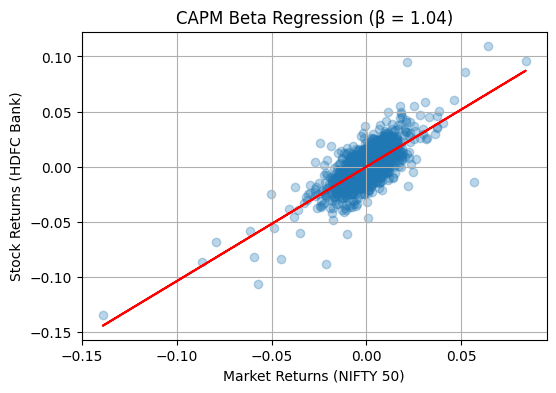

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(returns["Market_Return"], returns["Stock_Return"], alpha=0.3)
plt.plot(returns["Market_Return"], capm_model.predict(X), color="red")

plt.xlabel("Market Returns (NIFTY 50)")
plt.ylabel("Stock Returns (HDFC Bank)")
plt.title(f"CAPM Beta Regression (β = {beta:.2f})")
plt.grid(True)
plt.show()


Save beta for later stages:

In [7]:
beta_df = pd.DataFrame({
    "ticker": [stock_ticker],
    "beta": [beta],
    "alpha": [alpha]
})

beta_df


,ticker,beta,alpha
0,HDFCBANK.NS,1.037092,-0.000092


Optionally save:

In [8]:
beta_df.to_csv("../data/beta_hdfc.csv", index=False)
